In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import datetime as dt

## **Import data**

In [158]:
data_path=r'C:\AnalyticsProjects\ecommerce-transactions-insights\00_data\01_raw'

customers=pd.read_excel(data_path+'/'+'CustomersData.xlsx')
discount_coupons=pd.read_csv(data_path+'/'+'Discount_Coupon.csv')
orders=pd.read_csv(data_path+'/'+'Online_Sales.csv')
taxes=pd.read_excel(data_path+'/'+'Tax_amount.xlsx')

In [159]:
customers.head()

,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


In [160]:
discount_coupons.head()

,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


In [161]:
orders.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


In [162]:
taxes.head()

,Product_Category,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


## **Renombramiento columnas**

Llevar nombres a lower case

In [163]:
orders.rename(columns={'CustomerID':'Customer_ID', 'Avg_Price': 'Product_Price'},inplace=True)
customers.rename(columns={'CustomerID':'Customer_ID'},inplace=True)

In [164]:
customers.columns=[col.lower() for col in customers.columns]
discount_coupons.columns=[col.lower() for col in discount_coupons.columns]
taxes.columns=[col.lower() for col in taxes.columns]
orders.columns=[col.lower() for col in orders.columns]
dataframes={
    'customer':customers,
    'discount coupons':discount_coupons,
    'orders':orders,
    'taxes':taxes
}
for name,df in dataframes.items():
    df.columns=[col.lower() for col in df.columns]
    print(name, list(df.columns))

customer ['customer_id', 'gender', 'location', 'tenure_months']
discount coupons ['month', 'product_category', 'coupon_code', 'discount_pct']
orders ['customer_id', 'transaction_id', 'transaction_date', 'product_sku', 'product_description', 'product_category', 'quantity', 'product_price', 'delivery_charges', 'coupon_status']
taxes ['product_category', 'gst']


## **Orders data**

In [165]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          52924 non-null  int64  
 1   transaction_id       52924 non-null  int64  
 2   transaction_date     52924 non-null  object 
 3   product_sku          52924 non-null  object 
 4   product_description  52924 non-null  object 
 5   product_category     52924 non-null  object 
 6   quantity             52924 non-null  int64  
 7   product_price        52924 non-null  float64
 8   delivery_charges     52924 non-null  float64
 9   coupon_status        52924 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ MB


In [166]:
orders['transaction_date']=pd.to_datetime(orders['transaction_date'], dayfirst=False)
orders.head()

,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,product_price,delivery_charges,coupon_status
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


In [167]:
orders['customer_id']=orders['customer_id'].astype('object')
orders['transaction_id']=orders['transaction_id'].astype('object')
orders['coupon_status']=orders['coupon_status'].astype('category')

In [168]:
orders.dtypes

customer_id                    object
transaction_id                 object
transaction_date       datetime64[ns]
product_sku                    object
product_description            object
product_category               object
quantity                        int64
product_price                 float64
delivery_charges              float64
coupon_status                category
dtype: object

In [169]:
orders.describe(include=[np.number])

,quantity,product_price,delivery_charges
count,52924.000000,52924.000000,52924.000000
mean,4.497638,52.237646,10.517630
std,20.104711,64.006882,19.475613
min,1.000000,0.390000,0.000000
25%,1.000000,5.700000,6.000000
50%,1.000000,16.990000,6.000000
75%,2.000000,102.130000,6.500000
max,900.000000,355.740000,521.360000


In [170]:
orders.isnull().sum()

customer_id            0
transaction_id         0
transaction_date       0
product_sku            0
product_description    0
product_category       0
quantity               0
product_price          0
delivery_charges       0
coupon_status          0
dtype: int64

In [171]:
orders.coupon_status.value_counts()

coupon_status
Clicked     26926
Used        17904
Not Used     8094
Name: count, dtype: int64

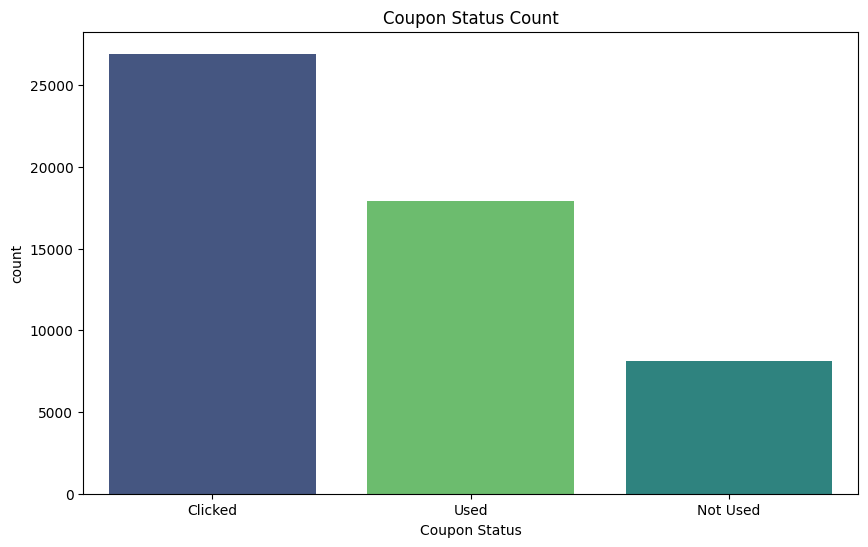

In [172]:
plt.figure(figsize=(10,6))
sns.countplot(x='coupon_status', data=orders, hue='coupon_status', order=orders['coupon_status'].value_counts().index, palette='viridis')
plt.title('Coupon Status Count')
plt.xlabel('Coupon Status')
plt.show()

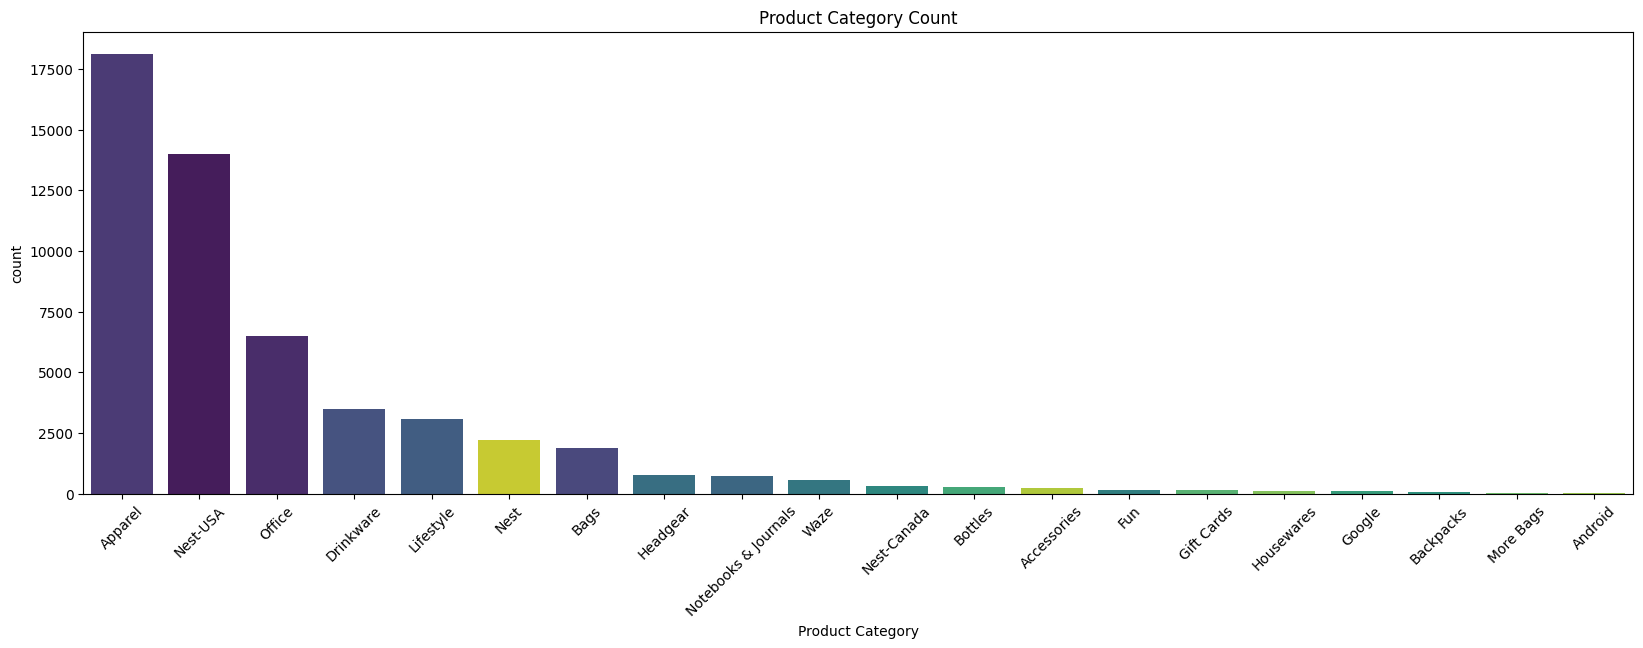

In [173]:
plt.figure(figsize=(20,6))
sns.countplot(x='product_category', data=orders, hue='product_category', order=orders['product_category'].value_counts().index, palette='viridis')
x=plt.xticks(rotation=45)
plt.title('Product Category Count')
plt.xlabel('Product Category')
plt.show()

## **Customer data**

In [174]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    1468 non-null   int64 
 1   gender         1468 non-null   object
 2   location       1468 non-null   object
 3   tenure_months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB


In [175]:
customers['customer_id']=customers['customer_id'].astype('object')

In [176]:
customers.describe(include=[np.number])

,tenure_months
count,1468.000000
mean,25.912125
std,13.959667
min,2.000000
25%,14.000000
50%,26.000000
75%,38.000000
max,50.000000


In [177]:
customers.isnull().sum()

customer_id      0
gender           0
location         0
tenure_months    0
dtype: int64

In [178]:
customers['customer_id'].nunique()

1468

In [179]:
customers['customer_id'].value_counts().max()

np.int64(1)

In [180]:
customers.gender.value_counts()

gender
F    934
M    534
Name: count, dtype: int64

In [181]:
customers.location.value_counts()

location
California       464
Chicago          456
New York         324
New Jersey       149
Washington DC     75
Name: count, dtype: int64

## **Discount Coupon**

In [182]:
discount_coupons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             204 non-null    object
 1   product_category  204 non-null    object
 2   coupon_code       204 non-null    object
 3   discount_pct      204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB


In [183]:
discount_coupons.isnull().sum()

month               0
product_category    0
coupon_code         0
discount_pct        0
dtype: int64

In [184]:
discount_coupons.month.value_counts()

month
Jan    17
Feb    17
Mar    17
Apr    17
May    17
Jun    17
Jul    17
Aug    17
Sep    17
Oct    17
Nov    17
Dec    17
Name: count, dtype: int64

In [185]:
discount_coupons.product_category.value_counts()

product_category
Apparel                 12
Nest-USA                12
Office                  12
Drinkware               12
Lifestyle               12
Bags                    12
Notebooks               12
Headgear                12
Nest                    12
Waze                    12
Bottles                 12
Nest-Canada             12
Housewares              12
Accessories             12
Gift Cards              12
Notebooks & Journals    12
Android                 12
Name: count, dtype: int64

In [186]:
discount_coupons.coupon_code.unique(), len(discount_coupons.coupon_code.unique())

(array(['SALE10', 'SALE20', 'SALE30', 'ELEC10', 'ELEC20', 'ELEC30',
        'OFF10', 'OFF20', 'OFF30', 'EXTRA10', 'EXTRA20', 'EXTRA30',
        'AIO10', 'AIO20', 'AIO30', 'NOTES10', 'NOTES20', 'NOTES30',
        'HGEAR10', 'HGEAR20', 'HGEAR30', 'NE10', 'NE20', 'NE30', 'WEMP10',
        'WEMP20', 'WEMP30', 'BT10', 'BT20', 'BT30', 'NCA10', 'NCA20',
        'NCA30', 'HOU10', 'HOU20', 'HOU30', 'ACC10', 'ACC20', 'ACC30',
        'GC10', 'GC20', 'GC30', 'NJ10', 'NJ20', 'NJ30', 'AND10', 'AND20',
        'AND30'], dtype=object),
 48)

In [187]:
discount_coupons['coupon_code'].value_counts(), discount_coupons['coupon_code'].value_counts().max()

(coupon_code
 EXTRA20    8
 EXTRA30    8
 EXTRA10    8
 SALE10     4
 ELEC20     4
 SALE20     4
 SALE30     4
 ELEC10     4
 OFF20      4
 OFF10      4
 ELEC30     4
 OFF30      4
 AIO10      4
 AIO20      4
 AIO30      4
 NOTES10    4
 NOTES20    4
 NOTES30    4
 HGEAR10    4
 HGEAR20    4
 HGEAR30    4
 NE10       4
 NE20       4
 NE30       4
 WEMP10     4
 WEMP20     4
 WEMP30     4
 BT10       4
 BT20       4
 BT30       4
 NCA10      4
 NCA20      4
 NCA30      4
 HOU10      4
 HOU20      4
 HOU30      4
 ACC10      4
 ACC20      4
 ACC30      4
 GC10       4
 GC20       4
 GC30       4
 NJ10       4
 NJ20       4
 NJ30       4
 AND10      4
 AND20      4
 AND30      4
 Name: count, dtype: int64,
 np.int64(8))

In [188]:
discount_coupons[['month','product_category','coupon_code']].value_counts()

month  product_category      coupon_code
Apr    Accessories           ACC10          1
       Android               AND10          1
       Apparel               SALE10         1
       Bags                  AIO10          1
       Bottles               BT10           1
                                           ..
Sep    Nest-USA              ELEC30         1
       Notebooks             NOTES30        1
       Notebooks & Journals  NJ30           1
       Office                OFF30          1
       Waze                  WEMP30         1
Name: count, Length: 204, dtype: int64

In [189]:
discount_coupons.discount_pct.value_counts()

discount_pct
10    68
20    68
30    68
Name: count, dtype: int64

## **Tax data**

GST: Goods and Services Tax

In [190]:
taxes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_category  20 non-null     object 
 1   gst               20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 452.0+ bytes


In [191]:
taxes.isnull().sum()

product_category    0
gst                 0
dtype: int64

In [192]:
taxes.product_category.value_counts(), len(taxes.product_category.value_counts())

(product_category
 Nest-USA                1
 Office                  1
 Apparel                 1
 Bags                    1
 Drinkware               1
 Lifestyle               1
 Notebooks & Journals    1
 Headgear                1
 Waze                    1
 Fun                     1
 Nest-Canada             1
 Backpacks               1
 Google                  1
 Bottles                 1
 Gift Cards              1
 More Bags               1
 Housewares              1
 Android                 1
 Accessories             1
 Nest                    1
 Name: count, dtype: int64,
 20)

In [193]:
taxes.gst.describe()

count    20.000000
mean      0.116500
std       0.052443
min       0.050000
25%       0.087500
50%       0.100000
75%       0.180000
max       0.180000
Name: gst, dtype: float64

## **Data merging (Integration)**

#### **Customers on Orders**

In [241]:
data=orders.merge(customers, on='customer_id', how='left')

In [242]:
data.head()

,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,product_price,delivery_charges,coupon_status,gender,location,tenure_months
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,M,Chicago,12
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,M,Chicago,12
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,M,Chicago,12
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,M,Chicago,12
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,M,Chicago,12


#### **Coupons on Orders**

In [243]:
data['year'], data['month_num'], data['day']=data['transaction_date'].dt.year, data['transaction_date'].dt.month, data['transaction_date'].dt.day
#data['month_name']=data['transaction_date'].dt.month_name()
data['month']=data['transaction_date'].dt.strftime('%b')
data['day_name']=data['transaction_date'].dt.day_name()
data['week']=data['transaction_date'].dt.isocalendar().week
data['quarter']=data['transaction_date'].dt.quarter
data.head()

,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,product_price,delivery_charges,coupon_status,gender,location,tenure_months,year,month_num,day,month,day_name,week,quarter
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,M,Chicago,12,2019,1,1,Jan,Tuesday,1,1
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,M,Chicago,12,2019,1,1,Jan,Tuesday,1,1
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,M,Chicago,12,2019,1,1,Jan,Tuesday,1,1
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,M,Chicago,12,2019,1,1,Jan,Tuesday,1,1
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,M,Chicago,12,2019,1,1,Jan,Tuesday,1,1


In [244]:
data=data.merge(discount_coupons, on=['month','product_category'], how='left')
data.head()

,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,product_price,delivery_charges,coupon_status,...,tenure_months,year,month_num,day,month,day_name,week,quarter,coupon_code,discount_pct
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,12,2019,1,1,Jan,Tuesday,1,1,ELEC10,10.0
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,12,2019,1,1,Jan,Tuesday,1,1,ELEC10,10.0
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,12,2019,1,1,Jan,Tuesday,1,1,OFF10,10.0
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,12,2019,1,1,Jan,Tuesday,1,1,SALE10,10.0
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,12,2019,1,1,Jan,Tuesday,1,1,AIO10,10.0


#### **Taxes on Orders**

In [245]:
data=data.merge(taxes, on='product_category', how='left')
data.head()

,customer_id,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,product_price,delivery_charges,coupon_status,...,year,month_num,day,month,day_name,week,quarter,coupon_code,discount_pct,gst
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,2019,1,1,Jan,Tuesday,1,1,ELEC10,10.0,0.10
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,2019,1,1,Jan,Tuesday,1,1,ELEC10,10.0,0.10
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,2019,1,1,Jan,Tuesday,1,1,OFF10,10.0,0.10
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,2019,1,1,Jan,Tuesday,1,1,SALE10,10.0,0.18
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,2019,1,1,Jan,Tuesday,1,1,AIO10,10.0,0.18


### **Ordenar columnas**

In [246]:
data.columns

Index(['customer_id', 'transaction_id', 'transaction_date', 'product_sku',
       'product_description', 'product_category', 'quantity', 'product_price',
       'delivery_charges', 'coupon_status', 'gender', 'location',
       'tenure_months', 'year', 'month_num', 'day', 'month', 'day_name',
       'week', 'quarter', 'coupon_code', 'discount_pct', 'gst'],
      dtype='object')

In [247]:
ordered_columns = [
    'customer_id', 'gender', 'location', 'tenure_months',  
    'transaction_id', 'transaction_date',  
    'product_sku', 'product_description', 'product_category', 'quantity', 'product_price',  
    'coupon_status', 'coupon_code', 'discount_pct',  
    'delivery_charges', 'gst',  
    'year', 'month', 'day_name', 'week', 'quarter'
]
data=data[ordered_columns]
data.head()

,customer_id,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,coupon_status,coupon_code,discount_pct,delivery_charges,gst,year,month,day_name,week,quarter
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,Used,ELEC10,10.0,6.5,0.10,2019,Jan,Tuesday,1,1
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,Used,ELEC10,10.0,6.5,0.10,2019,Jan,Tuesday,1,1
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,Used,OFF10,10.0,6.5,0.10,2019,Jan,Tuesday,1,1
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,Not Used,SALE10,10.0,6.5,0.18,2019,Jan,Tuesday,1,1
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,Used,AIO10,10.0,6.5,0.18,2019,Jan,Tuesday,1,1


## **Generación de campos**

**Descuento total, Impuestos totales, Precio final**

In [253]:
data['efective_discount'] = data.apply(lambda x: x['discount_pct'] / 100 if x['coupon_status'] == 'Used' else 0, axis=1)

In [254]:
data['invoice_value'] = data['quantity'] * data['product_price'] * (1 - data['efective_discount']) * (1 + data['gst']) + data['delivery_charges']
data.head()

,customer_id,gender,location,tenure_months,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,...,discount_pct,delivery_charges,gst,year,month,day_name,week,quarter,efective_discount,invoice_value
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,10.0,6.5,0.10,2019,Jan,Tuesday,1,1,0.1,158.6729
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,...,10.0,6.5,0.10,2019,Jan,Tuesday,1,1,0.1,158.6729
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,...,10.0,6.5,0.10,2019,Jan,Tuesday,1,1,0.1,8.5295
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,...,10.0,6.5,0.18,2019,Jan,Tuesday,1,1,0.0,109.9270
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,...,10.0,6.5,0.18,2019,Jan,Tuesday,1,1,0.1,24.0230


In [255]:
data[
    [
    'transaction_id', 'transaction_date',  
    'product_sku', 'product_description', 'product_category', 'quantity', 'product_price',  
    'coupon_status', 'coupon_code', 'discount_pct',  
    'delivery_charges', 'gst', 'invoice_value'
    ]
]

,transaction_id,transaction_date,product_sku,product_description,product_category,quantity,product_price,coupon_status,coupon_code,discount_pct,delivery_charges,gst,invoice_value
0,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,Used,ELEC10,10.0,6.50,0.10,158.67290
1,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,Used,ELEC10,10.0,6.50,0.10,158.67290
2,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,Used,OFF10,10.0,6.50,0.10,8.52950
3,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,Not Used,SALE10,10.0,6.50,0.18,109.92700
4,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,Used,AIO10,10.0,6.50,0.18,24.02300
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,Clicked,ELEC30,30.0,6.50,0.10,139.93000
52920,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,Used,SALE30,30.0,6.50,0.18,46.90792
52921,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,Used,ELEC30,30.0,6.50,0.10,123.44760
52922,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,Clicked,ELEC30,30.0,6.50,0.10,449.36000
